# How the supervised morphology axis works — one contrast, start to finish

Every number in `gene7_synthesis.ipynb` rests on a construction that is easy to state and easy to
misread, so this notebook walks it through on a single cohort where it works well:

> **`ctcf` vs matched controls, 34 °C, 30 hpf** — 12 crispants against 12 stage- and
> temperature-matched controls, leave-one-out AUC **0.89**, one of the 16 axes that passed the §1
> validation gate.

The panels answer six questions in order:

0. **Where does this cohort sit in the dataset as a whole?** All 553 GENE7 wells in 3D, then the
   same view with everything but the example greyed out.
1. **Is the perturbation visible in the raw morphology space at all?** PC1 vs PC2, no labels used.
2. **What does the supervised axis do differently?** The same 24 embryos, re-projected onto the
   discriminant.
3. **Where is the decision boundary, and who sits on the wrong side of it?**
4. **What does that boundary look like back in PC1-PC2?** The same cut, drawn in the space you
   started in.
5. **What does the ordering actually look like in pictures?**

**One thing to be clear about up front.** A two-class LDA has rank **one** — there is exactly one
discriminant direction, not two. The vertical axis in panels 2 and 3 is therefore *not* a second
discriminant. It is the leading direction of the remaining within-cohort variance after the
discriminant has been projected out: the biggest thing that varies among these embryos that is
*not* the crispant/control contrast. It is there to show the cloud's shape, not to separate groups.


In [12]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
import lda_contrasts as lc
import lda_plots as lp
import gene7_config as cfg

lp.use_house_style()
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
FIGURES = cfg.figure_dir("axis_walkthrough")

TARGET, TEMPERATURE, TIMEPOINT = "ctcf", 34.0, 30.0
CONTROL_COLOUR, CRISPANT_COLOUR = lp.CONTROL_COLOUR, lp.CRISPANT_COLOUR

scores = pd.read_csv(HERE / "data" / "gene7_global_scores.csv")
columns = lc.shared_columns(scores)               # G00..G04, the 5D working subspace

axis = lc.fit_contrast(scores, target=TARGET, temperature=TEMPERATURE, timepoint=TIMEPOINT)
members = scores.loc[(scores["temperature"] == TEMPERATURE)
                     & (scores["timepoint_seq"] == TIMEPOINT)
                     & (scores["perturbation_group"].isin([TARGET, lc.CONTROL_GROUP]))
                     ].reset_index(drop=True)
features = members.loc[:, columns].to_numpy(float)
labels = (members["perturbation_group"] == TARGET).to_numpy().astype(int)

print(f"{axis.label}")
print(f"  {axis.n_crispant} crispants vs {axis.n_control} controls in {len(columns)}D "
      f"({', '.join(columns)})")
print(f"  leave-one-out AUC {axis.loo_auc:.3f}   Mahalanobis separation {axis.separation:.2f}   "
      f"Ledoit-Wolf shrinkage {axis.shrinkage:.3f}")
print(f"  figures -> {FIGURES}")

ctcf vs ctrl | 34C | 30hpf
  12 crispants vs 12 controls in 5D (G00, G01, G02, G03, G04)
  leave-one-out AUC 0.889   Mahalanobis separation 2.35   Ledoit-Wolf shrinkage 0.157
  figures -> /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/axis_walkthrough


---

## 0. Where this cohort sits in the whole GENE7 dataset

Before zooming in on 24 embryos, it is worth seeing what the space they live in actually looks like.
All 553 GENE7 wells are plotted on the first three components of the shared morphology basis, which
between them carry **88%** of the variance.

**The dominant structure is not genotype — it is rearing temperature.** The layering is cleanest on
**PC3**, which is monotone in temperature (group means 24 °C → −0.65, 28 → −0.23, 34 → +0.04, 35 →
+0.86); PC1 and PC2 are also strongly temperature-driven but not monotone in it. That is expected —
temperature sets developmental rate, and the leading morphology components are largely reading stage.

Crispant target, by contrast, barely moves the cloud. Comparing the spread of group means on each
component, temperature beats target by **4×** on PC1, **14×** on PC2 and **5×** on PC3. The four
targets are not literally superimposed, but next to the temperature effect they are close to it.

That is the entire reason the analysis is built the way it is. A discriminant fit across the whole
dataset would find temperature, not genotype. So every contrast is fit **within a single temperature
and timepoint cell**, against its own matched controls.

**Three panels, same camera, same limits, same aspect — so they overlay directly:**

- **0a** — all 553 wells, in the grammar native to the morph plots in every other notebook:
  **colour = temperature, shape = target.**
- **0b** — the same rules, restricted to the example contrast: `ctcf` at 34 °C / 30 hpf plus its
  temperature-matched controls. Every embryo is at one temperature, so they all come out the **same
  colour** and are told apart by **shape** alone.
- **0c** — the same 24 embryos again, switched to the **blue/red circles** used by panels 1–5 and by
  the rest of this notebook. Colour stops meaning temperature and starts meaning class.

PC1-PC3 carry 88% of the variance across all 553 wells

spread of group means (SD across groups) -- temperature vs crispant target:
  PC1  temperature 0.80   target 0.19   (4.1x)   temp means: 24C=+1.11, 28C=-0.58, 34C=-0.92, 35C=+0.40
  PC2  temperature 0.34   target 0.02   (14.4x)   temp means: 24C=-0.08, 28C=-0.22, 34C=+0.57, 35C=-0.30
  PC3  temperature 0.55   target 0.10   (5.3x)   temp means: 24C=-0.65, 28C=-0.23, 34C=+0.04, 35C=+0.86

only PC3 is monotone in temperature -- the other two are driven by it but not ordered by it


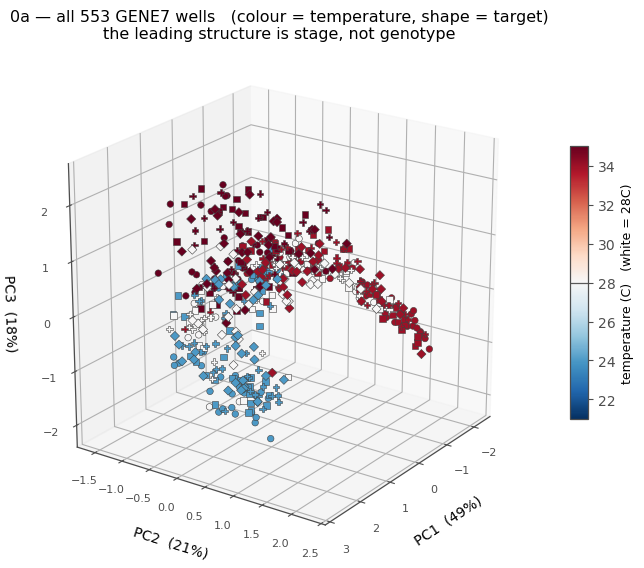

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

ELEV, AZIM = 22, 35                     # one camera for both panels, so they overlay
# Left edge kept off 0.0 so the rotated PC3 label has somewhere to live: these panels are saved
# with cropping disabled (bbox=None) so the two stay overlayable, which also means anything drawn
# outside the figure is simply lost rather than expanded into.
PANEL_RECT = [0.080, 0.02, 0.62, 0.90]  # identical axes rectangle in both, likewise

import plotting as pl                     # the morphospace plot helpers

# Panels 0a and 0b use the visual grammar native to the morph plots in every other notebook (see
# plotting.py): colour = rearing temperature on the 28C-anchored RdBu_r map, shape = perturbation
# target. Symbols are taken from plotting._symbol_map over the FULL four-target GENE7 group list,
# controls first, so a target keeps the same shape here as it has in the morphospace figures rather
# than being renumbered by whichever subset a panel happens to show.
PLOTLY_TO_MPL = {"circle": "o", "square": "s", "diamond": "D", "cross": "P",
                 "triangle-up": "^", "x": "X"}
SYMBOL = {group: PLOTLY_TO_MPL[symbol] for group, symbol in
          pl._symbol_map(sorted(scores["perturbation_group"].unique()), pl.SYMBOLS_2D).items()}
TEMP_LIMITS = cfg.temperature_limits(scores["temperature"])

# Panel 0c switches to the class colouring used by every later panel in this notebook.
MARKER = dict(s=72, edgecolor="0.15", linewidth=0.7)
# Every GENE7 well NOT in the example contrast, drawn as a grey dot behind the subset panels
# so 0b and 0c keep the shape of the full cloud visible.
BACKGROUND = dict(color="0.78", s=13, alpha=0.5, edgecolor="none")

all_features = scores.loc[:, columns].to_numpy(float)
variance_share = scores[columns].var(ddof=1) / scores[columns].var(ddof=1).sum()

# The 24 embryos of the example contrast, located inside the full table.
in_cohort = ((scores["temperature"] == TEMPERATURE)
             & (scores["timepoint_seq"] == TIMEPOINT)
             & (scores["perturbation_group"].isin([TARGET, lc.CONTROL_GROUP]))).to_numpy()
cohort_is_crispant = (scores.loc[in_cohort, "perturbation_group"] == TARGET).to_numpy()

LIMITS_3D = [(all_features[:, i].min() - 0.08 * np.ptp(all_features[:, i]),
              all_features[:, i].max() + 0.08 * np.ptp(all_features[:, i])) for i in range(3)]


def frame_3d(ax):
    """Camera, limits and labels shared by both panels."""
    ax.view_init(elev=ELEV, azim=AZIM)
    ax.set_xlim(*LIMITS_3D[0]); ax.set_ylim(*LIMITS_3D[1]); ax.set_zlim(*LIMITS_3D[2])
    ax.set_box_aspect((1, 1, 1))       # pinned, so 0a and 0b have the same aspect as well as
                                       # the same camera, limits, figsize and axes rectangle
    for index, name in enumerate(("x", "y", "z")):
        getattr(ax, f"set_{name}label")(f"PC{index + 1}  ({variance_share.iloc[index]:.0%})",
                                        labelpad=7)
    ax.tick_params(labelsize=8)
    return ax


def morphospace_scatter(ax, block, *, size):
    """Colour = temperature, shape = target -- the grammar used by the other morph notebooks."""
    order = sorted(block["perturbation_group"].unique(),
                   key=lambda g: (not str(g).lower().startswith("control"), str(g)))
    drawn = None
    for group in order:
        part = block.loc[block["perturbation_group"] == group]
        drawn = ax.scatter(part[columns[0]], part[columns[1]], part[columns[2]],
                           c=part["temperature"], cmap=cfg.TEMPERATURE_SCALE,
                           vmin=TEMP_LIMITS[0], vmax=TEMP_LIMITS[1], marker=SYMBOL[group],
                           s=size, edgecolor="0.25", linewidth=0.4, depthshade=False, zorder=3,
                           label=f"{group}  (n={len(part)})")
    return drawn


figure = plt.figure(figsize=(8.2, 6.2))
ax = frame_3d(figure.add_axes(PANEL_RECT, projection="3d"))
points = morphospace_scatter(ax, scores, size=22)
bar = figure.colorbar(points, cax=figure.add_axes([0.745, 0.28, 0.022, 0.44]))
bar.set_label(f"temperature (C)   (white = {cfg.REFERENCE_TEMPERATURE:.0f}C)", fontsize=9)
bar.ax.axhline(cfg.REFERENCE_TEMPERATURE, color="0.35", linewidth=0.9)
ax.set_title(f"0a — all {len(scores)} GENE7 wells   (colour = temperature, shape = target)\n"
             f"the leading structure is stage, not genotype", fontsize=11.5)
lp.save_inline(figure, FIGURES / "0a_all_embryos_3d", bbox=None)

print(f"PC1-PC3 carry {variance_share.iloc[:3].sum():.0%} of the variance across all "
      f"{len(scores)} wells\n")
print("spread of group means (SD across groups) -- temperature vs crispant target:")
for index in range(3):
    by_temperature = scores.groupby("temperature")[columns[index]].mean()
    by_target = scores.groupby("perturbation_group")[columns[index]].mean()
    print(f"  PC{index + 1}  temperature {by_temperature.std(ddof=0):.2f}   "
          f"target {by_target.std(ddof=0):.2f}   "
          f"({by_temperature.std(ddof=0) / by_target.std(ddof=0):.1f}x)   "
          f"temp means: {', '.join(f'{k:g}C={v:+.2f}' for k, v in by_temperature.items())}")
print("\nonly PC3 is monotone in temperature -- the other two are driven by it but not ordered by it")

24 embryos of 553 wells (4.3% of the dataset)
cohort SD / dataset SD, per component: PC1 0.68, PC2 0.44, PC3 0.61
  -- tightest on PC2, the component temperature separates most strongly: the cohort sits in
     one thin layer. It still spreads along PC1 (0.68 of the dataset SD), and THAT residual
     within-cohort variation is what the discriminant has to work with.


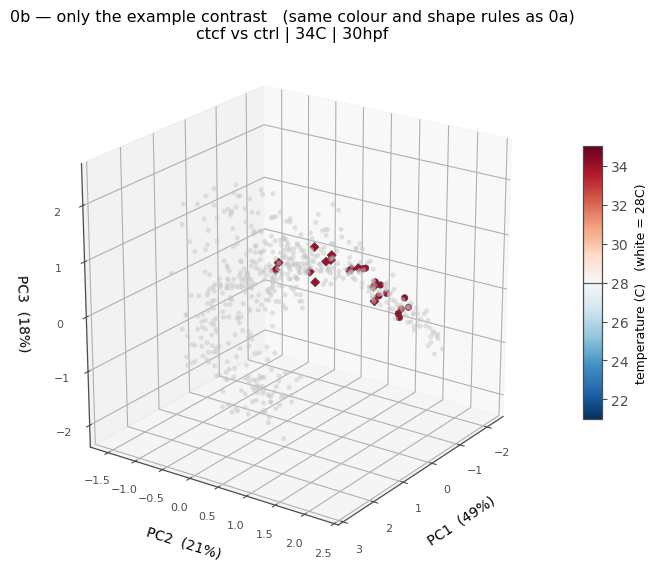

In [14]:
figure = plt.figure(figsize=(8.2, 6.2))          # identical figsize, rect and camera to 0a
ax = frame_3d(figure.add_axes(PANEL_RECT, projection="3d"))

background = all_features[~in_cohort]
ax.scatter(background[:, 0], background[:, 1], background[:, 2], **BACKGROUND, zorder=1)

cohort_block = scores.loc[in_cohort]
cohort = all_features[in_cohort]
points = morphospace_scatter(ax, cohort_block, size=22)
bar = figure.colorbar(points, cax=figure.add_axes([0.745, 0.28, 0.022, 0.44]))
bar.set_label(f"temperature (C)   (white = {cfg.REFERENCE_TEMPERATURE:.0f}C)", fontsize=9)
bar.ax.axhline(cfg.REFERENCE_TEMPERATURE, color="0.35", linewidth=0.9)
ax.set_title(f"0b — only the example contrast   (same colour and shape rules as 0a)\n"
             f"{axis.label}", fontsize=11.5)
lp.save_inline(figure, FIGURES / "0b_cohort_morphospace_3d", bbox=None)

# How local is this cohort? Compare its spread to the spread of the whole dataset, per component.
cohort_sd = cohort.std(axis=0, ddof=1)
global_sd = all_features.std(axis=0, ddof=1)
print(f"{int(in_cohort.sum())} embryos of {len(scores)} wells "
      f"({in_cohort.mean():.1%} of the dataset)")
print("cohort SD / dataset SD, per component: "
      f"{', '.join(f'PC{i+1} {cohort_sd[i] / global_sd[i]:.2f}' for i in range(3))}")
print("  -- tightest on PC2, the component temperature separates most strongly: the cohort sits in")
print("     one thin layer. It still spreads along PC1 (0.68 of the dataset SD), and THAT residual")
print("     within-cohort variation is what the discriminant has to work with.")

PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/axis_walkthrough/0c_cohort_classes_3d.png')

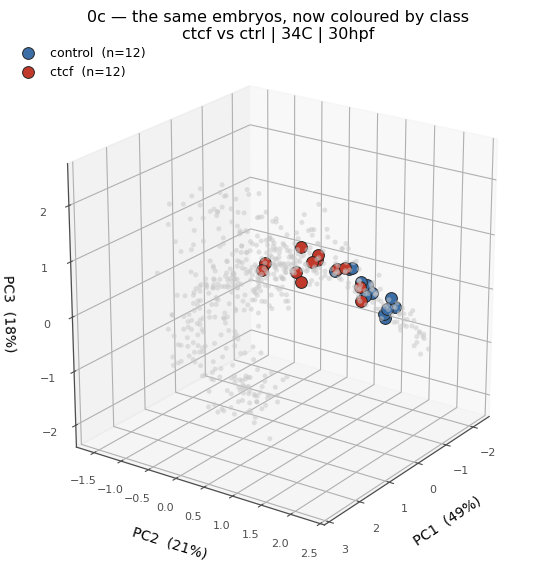

In [15]:
figure = plt.figure(figsize=(8.2, 6.2))          # identical figsize, rect and camera again
ax = frame_3d(figure.add_axes(PANEL_RECT, projection="3d"))

# Same 24 embryos, same 3D coordinates -- only the encoding changes. From here to the end of the
# notebook colour means CLASS, not temperature, and every marker is a circle: temperature is
# constant within this cohort, so the colour channel is free to carry the thing being tested.
ax.scatter(background[:, 0], background[:, 1], background[:, 2], **BACKGROUND, zorder=1)

for value, colour, name in ((False, CONTROL_COLOUR, "control"), (True, CRISPANT_COLOUR, TARGET)):
    mask = cohort_is_crispant == value
    ax.scatter(cohort[mask, 0], cohort[mask, 1], cohort[mask, 2],
               color=colour, marker="o", **MARKER, depthshade=False, zorder=3,
               label=f"{name}  (n={int(mask.sum())})")

figure.legend(loc="upper left", bbox_to_anchor=(0.055, 0.90), fontsize=9)
ax.set_title(f"0c — the same embryos, now coloured by class\n{axis.label}", fontsize=11.5)
lp.save_inline(figure, FIGURES / "0c_cohort_classes_3d", bbox=None)

---

## 1. Raw morphology space — the first two principal components

No labels are used to build these axes. PC1 and PC2 are the two directions of greatest variance in
the GENE7-native morphology basis, and the colouring is applied only afterwards.

This is the honest starting point: if the perturbation dominated morphological variation, the two
colours would already be separated here.

centroid gap in the PC1-PC2 plane : [1.006 0.474]
the two leading PCs carry 67% of this cohort's 5D variance


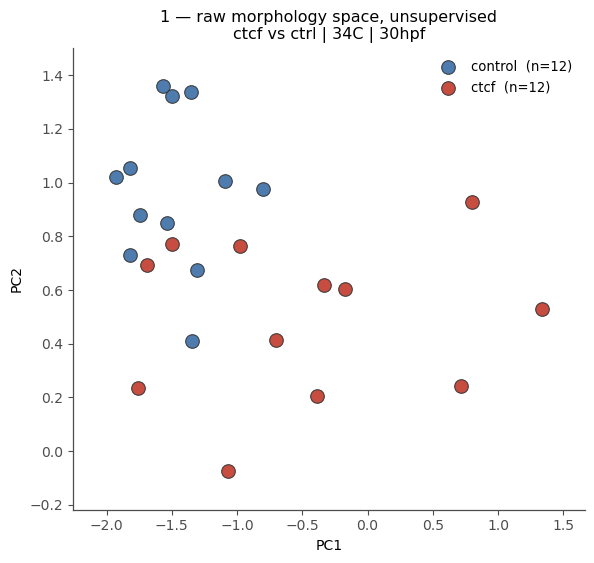

In [16]:
def scatter(ax, x, y, *, xlabel, ylabel, title):
    for value, colour, name in ((0, CONTROL_COLOUR, "control"), (1, CRISPANT_COLOUR, TARGET)):
        mask = labels == value
        ax.scatter(x[mask], y[mask], s=96, color=colour, edgecolor="0.2", linewidth=0.8,
                   alpha=0.9, zorder=3, label=f"{name}  (n={int(mask.sum())})")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11.5)
    ax.legend(fontsize=9.5, loc="best")
    return ax


total_variance = features.var(axis=0, ddof=1).sum()
share = features.var(axis=0, ddof=1) / total_variance

# Limits fixed here and reused by panel 4, so the two PCA views are directly comparable.
pc_pad_x = 0.10 * np.ptp(features[:, 0]); pc_pad_y = 0.10 * np.ptp(features[:, 1])
PCXLIM = (features[:, 0].min() - pc_pad_x, features[:, 0].max() + pc_pad_x)
PCYLIM = (features[:, 1].min() - pc_pad_y, features[:, 1].max() + pc_pad_y)

figure, ax = plt.subplots(figsize=(6.6, 6.0))
scatter(ax, features[:, 0], features[:, 1], xlabel="PC1", ylabel="PC2",
        title=f"1 — raw morphology space, unsupervised\n{axis.label}")
ax.set_xlim(PCXLIM); ax.set_ylim(PCYLIM)
lp.save_inline(figure, FIGURES / "1_raw_pca")

separation_pc = abs(features[labels == 1, :2].mean(0) - features[labels == 0, :2].mean(0))
print(f"centroid gap in the PC1-PC2 plane : {separation_pc.round(3)}")
print(f"the two leading PCs carry {share[:2].sum():.0%} of this cohort's 5D variance")

---

## 2. The same 24 embryos, re-projected onto the discriminant

The horizontal axis is now the **shrunken-LDA discriminant** — the single direction in the 5D
subspace that best separates the two labelled groups, given a Ledoit–Wolf regularised
within-class covariance. Each embryo's coordinate is its signed distance `s` from the separating
hyperplane, which is exactly the predictor used in every regression in the synthesis notebook.

The vertical axis is the **leading residual direction**: the largest remaining axis of variation
after the discriminant has been projected out. It carries no discriminative claim — a two-class LDA
produces one direction and one only. It is drawn so the cloud's shape is visible rather than
collapsing everything onto a line.

Note what this projection *is not*: it is not a rotation that "found" the separation. It used the
labels. The question §1 of the synthesis notebook asks — whether that separation generalises to
held-out embryos — is what the leave-one-out AUC and its permutation null are for.

angle between the discriminant and PC1 : 76 deg
s: controls -0.43 +/- 0.31 | ctcf +0.43 +/- 0.43


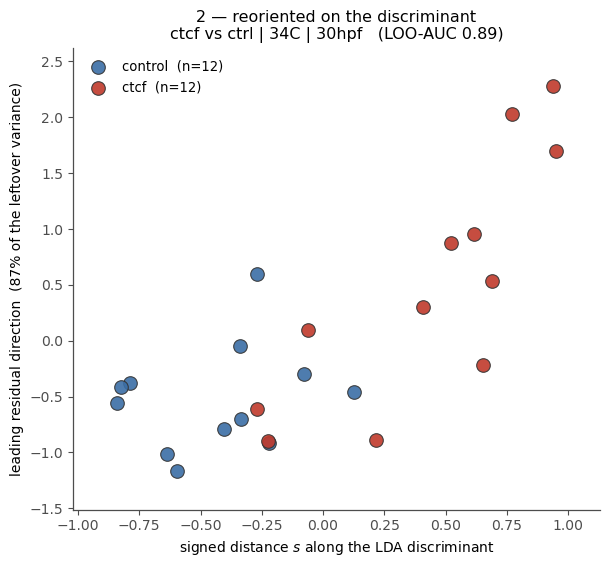

In [17]:
direction = axis.direction                                   # unit vector, 5D

# Take s straight from the fit rather than recomputing it. `axis.direction` is normalised while
# `axis.intercept` belongs to the UNnormalised weights, so feeding the pair to signed_distance()
# returns an uncentred score -- the boundary lands nowhere near zero and every error count is wrong.
# This is also the exact predictor every regression in the synthesis notebook consumes.
s = axis.scores["s"].to_numpy()
assert (axis.scores["is_crispant"].to_numpy() == labels).all(), "row order diverged"

residual = features - np.outer(features @ direction, direction)
residual = residual - residual.mean(axis=0)
_, singular, right = np.linalg.svd(residual, full_matrices=False)
second = right[0]                                            # leading residual direction
u = features @ second
u = u - u.mean()

residual_share = singular[0] ** 2 / (singular ** 2).sum()

# One set of limits for panels 2 and 3 so they are directly comparable / overlayable.
pad_x = 0.10 * (s.max() - s.min()); pad_y = 0.10 * (u.max() - u.min())
XLIM = (s.min() - pad_x, s.max() + pad_x)
YLIM = (u.min() - pad_y, u.max() + pad_y)

figure, ax = plt.subplots(figsize=(6.8, 6.0))
scatter(ax, s, u,
        xlabel="signed distance $s$ along the LDA discriminant",
        ylabel=f"leading residual direction  ({residual_share:.0%} of the leftover variance)",
        title=f"2 — reoriented on the discriminant\n{axis.label}   (LOO-AUC {axis.loo_auc:.2f})")
ax.set_xlim(XLIM); ax.set_ylim(YLIM)
lp.save_inline(figure, FIGURES / "2_lda_space")

print(f"angle between the discriminant and PC1 : "
      f"{lc.angle_between(direction, np.eye(len(columns))[0]):.0f} deg")
print(f"s: controls {s[labels==0].mean():+.2f} +/- {s[labels==0].std(ddof=1):.2f} | "
      f"{TARGET} {s[labels==1].mean():+.2f} +/- {s[labels==1].std(ddof=1):.2f}")

---

## 3. The decision boundary

The hyperplane sits at **`s = 0`** by construction — equal priors put it at the midpoint of the two
class centroids. In this projection it is a vertical line, and every embryo on the wrong side of it
is a misclassification *of the fitted model*.

Two error counts are reported in the title, and conflating them is the easiest mistake to make here:

- **in-sample** — every embryo on the wrong side of the line, scored by the fit that saw all 24.
- **leave-one-out** — scored by a discriminant refit without that embryo. This is the honest count,
  and it is what the leave-one-out AUC summarises.

They are 4 and 5 here, and the difference is smaller than it looks: 4 of the 5 leave-one-out errors
are misclassified by the full-data fit as well. Only one embryo genuinely changes status — a control
at `s = -0.268` that moves to `s_loo = +0.003`, which is 0.003 past the boundary and should be read
as a coin toss rather than a reclassification.

in-sample errors      : 4/24
leave-one-out errors  : 5/24  <- the honest count
  wrong both ways     : 4
  wrong only under LOO: 1  (the only true flip)
leave-one-out AUC     : 0.889   permutation p = 0.0020
null 95th percentile  : 0.729  (the bar the observed AUC had to clear)


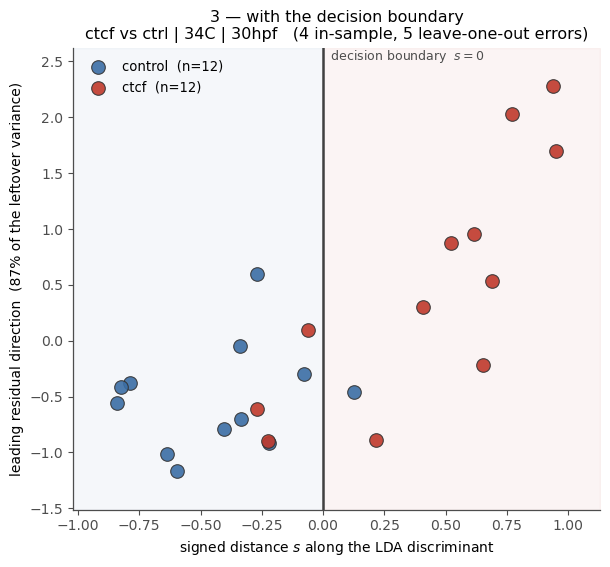

In [18]:
loo = axis.scores["s_loo"].to_numpy()
misfit = (s > 0).astype(int) != labels
loo_misfit = (loo > 0).astype(int) != labels

figure, ax = plt.subplots(figsize=(6.8, 6.0))            # identical size and limits to panel 2
scatter(ax, s, u,
        xlabel="signed distance $s$ along the LDA discriminant",
        ylabel=f"leading residual direction  ({residual_share:.0%} of the leftover variance)",
        title=f"3 \u2014 with the decision boundary\n{axis.label}   "
              f"({int(misfit.sum())} in-sample, {int(loo_misfit.sum())} leave-one-out errors)")
ax.set_xlim(XLIM); ax.set_ylim(YLIM)
ax.axvline(0, color="0.25", linestyle="-", linewidth=1.8, zorder=2)
ax.fill_betweenx(YLIM, XLIM[0], 0, color=CONTROL_COLOUR, alpha=0.05, zorder=0)
ax.fill_betweenx(YLIM, 0, XLIM[1], color=CRISPANT_COLOUR, alpha=0.05, zorder=0)
ax.text(0.0, YLIM[1], "  decision boundary  $s=0$", fontsize=9, color="0.3", va="top")
lp.save_inline(figure, FIGURES / "3_decision_boundary")

print(f"in-sample errors      : {int(misfit.sum())}/{len(labels)}")
print(f"leave-one-out errors  : {int(loo_misfit.sum())}/{len(labels)}  <- the honest count")
print(f"  wrong both ways     : {int((misfit & loo_misfit).sum())}")
print(f"  wrong only under LOO: {int((~misfit & loo_misfit).sum())}  (the only true flip)")
print(f"leave-one-out AUC     : {axis.loo_auc:.3f}   permutation p = {axis.perm_p_auc:.4f}")
print(f"null 95th percentile  : {axis.null_auc_p95:.3f}  (the bar the observed AUC had to clear)")

---

## 4. The same boundary, drawn back in PC1–PC2

Panels 2 and 3 rotated the data so the discriminant lay along the x-axis, which makes the boundary a
vertical line but leaves you looking at a space you did not start in. This panel puts the cut back
into the raw PC1–PC2 view of panel 1 — same points, same axes, same limits.

**The line is a slice, not a projection, and the distinction matters.** The boundary is a hyperplane
in 5D: `w·x + b = 0`. It does not project down to a line in PC1–PC2, because where it falls depends
on an embryo's other three coordinates. What is drawn is its intersection with the PC1–PC2 plane
taken **through the mean of PC3–PC5**, which is a genuine line but only exact for embryos sitting at
that mean.

In general that means points can sit on the "wrong" side of the drawn line while being classified
correctly in 5D, and vice versa — their PC3–PC5 coordinates move them off the slice. **In this cohort
that does not happen: the slice reproduces the full 5D verdict for all 24 embryos** (checked below,
0 disagreements), so the 4 points visibly stranded on the wrong side are the same 4 in-sample errors
panel 3 counts. That is a property of this particular cohort, not a guarantee — the slice is still an
approximation and should not be trusted to adjudicate borderline cases in general.

**Panel 3 remains the honest picture of the classifier; this one shows where the cut sits in the
space you can actually interpret.**

errors implied by the DRAWN line   : 4/24
errors under the full 5D rule      : 4/24  (panel 3)
embryos the slice places differently from the 5D rule : 0   <- 0 means the slice is faithful HERE; it is not guaranteed to be


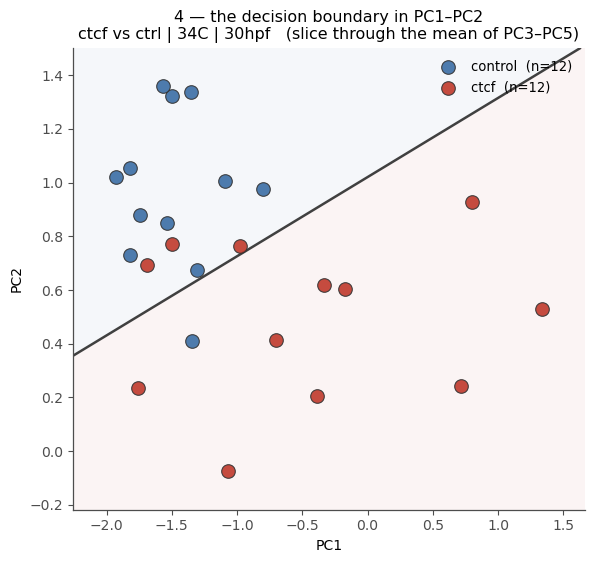

In [19]:
weights, intercept, _ = lc.fit_discriminant(features, labels)

# Slice the 5D hyperplane with the PC1-PC2 plane taken through the mean of the remaining
# components: w1*x1 + w2*x2 + (w3..w5 . mean(x3..x5) + b) = 0, a line in (PC1, PC2).
offset = float(weights[2:] @ features[:, 2:].mean(axis=0) + intercept)

grid_x, grid_y = np.meshgrid(np.linspace(*PCXLIM, 400), np.linspace(*PCYLIM, 400))
slice_score = weights[0] * grid_x + weights[1] * grid_y + offset

figure, ax = plt.subplots(figsize=(6.6, 6.0))            # identical size and limits to panel 1
ax.contourf(grid_x, grid_y, slice_score, levels=[slice_score.min(), 0, slice_score.max()],
            colors=[CONTROL_COLOUR, CRISPANT_COLOUR], alpha=0.05, zorder=0)
ax.contour(grid_x, grid_y, slice_score, levels=[0], colors=["0.25"], linewidths=1.8, zorder=2)
scatter(ax, features[:, 0], features[:, 1], xlabel="PC1", ylabel="PC2",
        title=f"4 \u2014 the decision boundary in PC1\u2013PC2\n{axis.label}   "
              f"(slice through the mean of PC3\u2013PC5)")
ax.set_xlim(PCXLIM); ax.set_ylim(PCYLIM)
lp.save_inline(figure, FIGURES / "4_boundary_in_pca")

# How much does the slice mislead? Compare its verdict against the true 5D sign of s.
slice_side = (features[:, 0] * weights[0] + features[:, 1] * weights[1] + offset) > 0
true_side = s > 0
print(f"errors implied by the DRAWN line   : {int((slice_side != labels.astype(bool)).sum())}/{len(labels)}")
print(f"errors under the full 5D rule      : {int((true_side != labels.astype(bool)).sum())}/{len(labels)}  "
      f"(panel 3)")
print(f"embryos the slice places differently from the 5D rule : {int((slice_side != true_side).sum())}"
      f"   <- 0 means the slice is faithful HERE; it is not guaranteed to be")

---

## 5. The ordering, in pictures

`s` is **one scalar per embryo on one shared axis** — the signed distance from the single
hyperplane. Controls and crispants are scored by the same function and placed on the same ruler;
that is the whole point, because where the controls land inside the crispant ordering is what tells
you whether the axis separates them. Border colour is the class: **blue = control, red = crispant**.

So a control and a crispant sitting at nearly the same `s` is not an error — it is the overlap, and
it is exactly the four in-sample misclassifications from panel 3. Scores are printed to **three**
decimals here because two is genuinely misleading: this contrast has a crispant at `s = -0.2695` and
a control at `s = -0.2678`, distinct embryos 0.0017 apart, which both render as "-0.27" and read as
a duplicate or a mislabelling when they are neither.

Three strips follow: the pooled ordering, then each class on its own. All three share **one crop
box** — the union across all 24 embryos — so relative size and elongation stay comparable between
them. Cropping each strip to its own contents would silently rescale the classes against each other.

The raw snips are 576 × 256 with the embryo filling about a fifth of the frame; cropping recovers
roughly 5× the area at the same figure size.

24 embryos, 24 snips resolved on disk
shared crop box (top, bottom, left, right): (118, 461, 66, 192)


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/axis_walkthrough/5_strip_all.png')

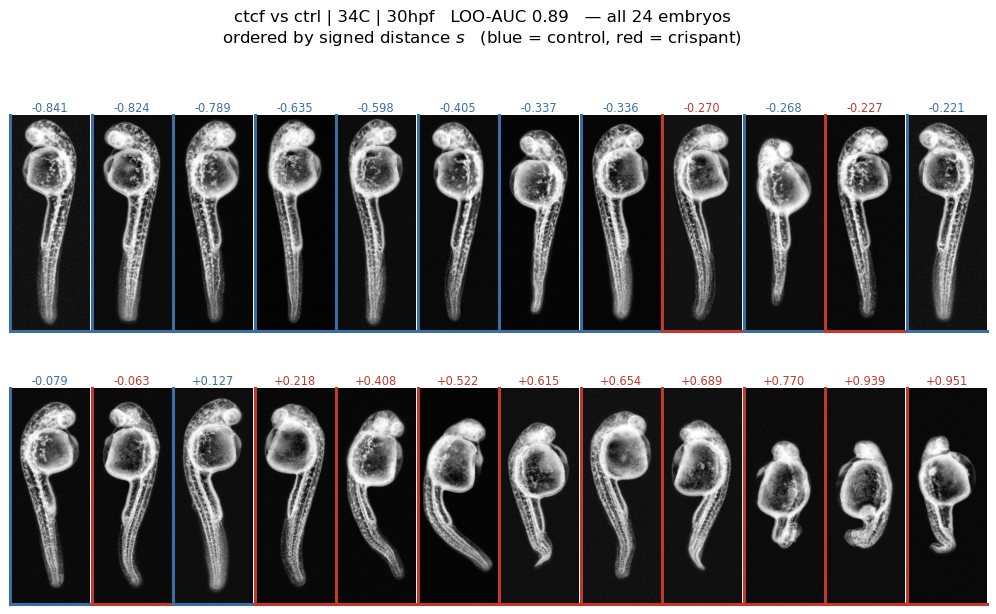

In [20]:
strip = lc.contrast_image_strip(axis)
print(f"{len(strip)} embryos, {int(strip['image_exists'].sum())} snips resolved on disk")

resolved = strip.loc[strip["image_exists"]]
crop = lp.strip_crop_box(resolved["image_path"])          # shared by all three strips below
print(f"shared crop box (top, bottom, left, right): {crop}")

figure = lp.contrast_strip_tight(
    strip, crop_box=crop, per_row=12,
    title=f"{axis.label}   LOO-AUC {axis.loo_auc:.2f}   — all 24 embryos",
    subtitle="ordered by signed distance $s$   (blue = control, red = crispant)")
lp.save_inline(figure, FIGURES / "5_strip_all")

  control : s from -0.841 to +0.127, mean -0.434, SD 0.308
  crispant: s from -0.270 to +0.951, mean +0.434, SD 0.428
  overlap zone spans 5 embryos (2 crispant, 3 control)


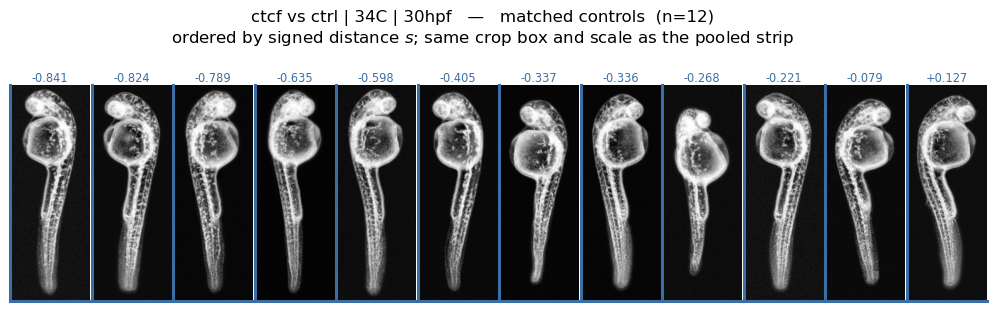

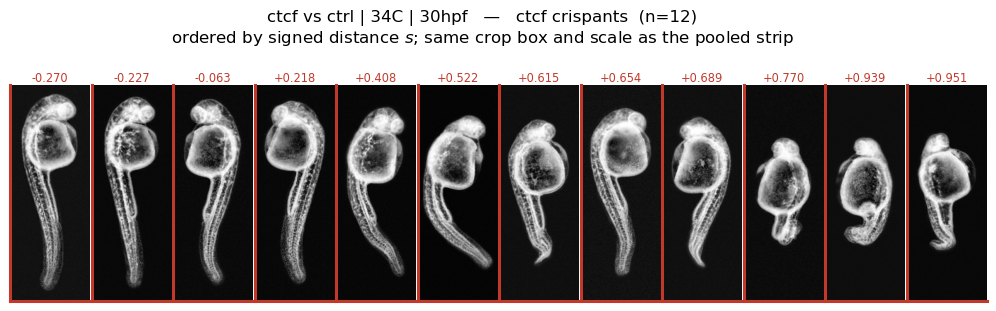

In [21]:
for is_crispant, name, tag in ((0, "matched controls", "control"),
                              (1, f"{TARGET} crispants", "crispant")):
    block = strip.loc[strip["is_crispant"] == is_crispant]
    figure = lp.contrast_strip_tight(
        block, crop_box=crop, per_row=12,
        title=f"{axis.label}   —   {name}  (n={len(block)})",
        subtitle="ordered by signed distance $s$; same crop box and scale as the pooled strip")
    lp.save_inline(figure, FIGURES / f"5_strip_{tag}")

for is_crispant, name in ((0, "control "), (1, "crispant")):
    values = strip.loc[strip["is_crispant"] == is_crispant, "s"]
    print(f"  {name}: s from {values.min():+.3f} to {values.max():+.3f}, "
          f"mean {values.mean():+.3f}, SD {values.std(ddof=1):.3f}")
overlap = strip.loc[(strip["s"] > strip.loc[strip['is_crispant'] == 1, "s"].min())
                    & (strip["s"] < strip.loc[strip['is_crispant'] == 0, "s"].max())]
print(f"  overlap zone spans {len(overlap)} embryos "
      f"({int(overlap['is_crispant'].sum())} crispant, {int((1 - overlap['is_crispant']).sum())} control)")

---

## What this cohort shows

**The unsupervised view gets partway there, and the supervised one is not simply a rotation of it.**
Panel 1 does show structure: the controls sit together at low PC1 and the crispants spread to the
right, centroids separated by 1.01 along an axis carrying 57% of the cohort's variance. But the
overlap is substantial — several crispants sit inside the control cloud, and no threshold on PC1
would cleanly split them. Panel 4 makes the same point from the other direction: the boundary drawn
in PC1–PC2 is a steeply tilted line, not a vertical one, because it is mostly built from PC3–PC5.

The instructive part is that **the discriminant sits 76° from PC1** — nearly orthogonal to the
direction that looks most separating by eye. That is not a contradiction. LDA works in the whitened
metric: it divides by the within-class covariance, so a direction with large *total* spread is
discounted unless the spread is between-class rather than within-class. The axis that separates best
per unit of within-class noise is mostly built from the lower-variance dimensions. This is also why
`gene7_unsupervised.ipynb` finds PC1 a poor stand-in for the discriminant across cohorts (median 63°
against a ~69° random baseline) even where, as here, PC1 is visibly doing something.

**The supervised axis does separate it, and the separation survives held-out scoring.** Panel 3's
leave-one-out error count is the number that matters; the in-sample count is optimistic by
construction. This contrast clears its permutation null comfortably, which is why it is one of the
16 axes marked *usable* in the synthesis notebook.

**The ordering is biologically legible.** Panel 5 shows a graded phenotype rather than a switch —
progressive tail shortening and curling, with the controls clustered at one end. That gradation is
precisely what the within-crispant slope term in §4–§5 regresses on, and why a graded score can
carry information that a binary label does not.

**What this notebook does not show.** That the axis generalises to other cohorts — the discriminant
directions do not align across contrasts (§2 of `gene7_lda_contrasts.ipynb`). Nor that morphological
severity tracks *molecular* severity; that is §3 of the synthesis notebook, and the answer is
"weakly". This is one cohort, chosen because it works.